In [ ]:
pip install tensorflow

In [ ]:
import sys
print(sys.version)
print(sys.executable)

In [ ]:
pip install pandas

In [ ]:
pip install scikit-learn

In [ ]:
pip install seaborn

In [ ]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [211]:
dataset = 'c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint.csv'
model_save_path = 'c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5'

# 分類数設定

In [212]:
NUM_CLASSES = 4

# 学習データ読み込み

In [213]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [214]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [215]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# モデル構築

In [216]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [217]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout_20 (Dropout)                 │ (None, 42)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 20)                  │             860 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_32 (Dense)                     │ (None, 4)                   │              44 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,114 (4.35 KB)

 Trainable params: 1,114 (4.35 KB)

 Non-trainable params: 0 (0.00 B)

In [218]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [219]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [220]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
63/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5378 - loss: 1.2000
Epoch 1: saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5



Epoch 1: finished saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5423 - loss: 1.1911 - val_accuracy: 0.6018 - val_loss: 1.0232
Epoch 2/1000
38/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6137 - loss: 1.0213 
Epoch 2: saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5



Epoch 2: finished saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6148 - loss: 1.0002 - val_accuracy: 0.6029 - val_loss: 0.9073
Epoch 3/1000
40/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6199 - loss: 0.9287 
Epoch 3: saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5



Epoch 3: finished saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6207 - loss: 0.9225 - val_accuracy: 0.6231 - val_loss: 0.8329
Epoch 4/1000
40/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6340 - loss: 0.8891 
Epoch 4: saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5



Epoch 4: finished saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6505 - loss: 0.8678 - val_accuracy: 0.7111 - val_loss: 0.7664
Epoch 5/1000
41/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6879 - loss: 0.8170 
Epoch 5: saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5


...


Epoch 169: finished saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8484 - loss: 0.4102 - val_accuracy: 0.9204 - val_loss: 0.2177
Epoch 170/1000
42/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8462 - loss: 0.4280 
Epoch 170: saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5



Epoch 170: finished saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8488 - loss: 0.4189 - val_accuracy: 0.9226 - val_loss: 0.2321
Epoch 171/1000
44/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8519 - loss: 0.4024 
Epoch 171: saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5



Epoch 171: finished saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8508 - loss: 0.4066 - val_accuracy: 0.9264 - val_loss: 0.2146
Epoch 172/1000
43/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8527 - loss: 0.4031 
Epoch 172: saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5



Epoch 172: finished saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8495 - loss: 0.4146 - val_accuracy: 0.9190 - val_loss: 0.2276
Epoch 173/1000
44/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8548 - loss: 0.4024 
Epoch 173: saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5



Epoch 173: finished saving model to c:/users/peter/hand-gesture-recognition-using-onnx/model/keypoint_classifier/keypoint_classifier.h5
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8550 - loss: 0.4010 - val_accuracy: 0.9211 - val_loss: 0.2243
Epoch 173: early stopping


In [221]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9211 - loss: 0.2243 


In [222]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [223]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[2.0128528e-02 1.7998350e-03 4.7789606e-05 9.7802395e-01]
3


# 混同行列

89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step


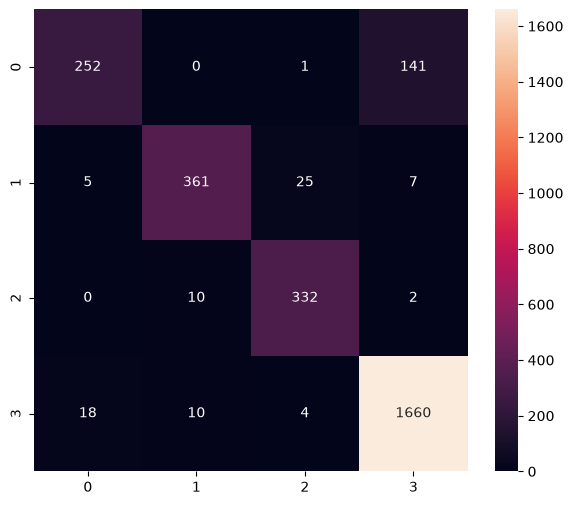

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.64      0.75       394
           1       0.95      0.91      0.93       398
           2       0.92      0.97      0.94       344
           3       0.92      0.98      0.95      1692

    accuracy                           0.92      2828
   macro avg       0.92      0.87      0.89      2828
weighted avg       0.92      0.92      0.92      2828



In [224]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [225]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

In [226]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\Peter\AppData\Local\Temp\tmp2ceuwfqd\assets


INFO:tensorflow:Assets written to: C:\Users\Peter\AppData\Local\Temp\tmp2ceuwfqd\assets


Saved artifact at 'C:\Users\Peter\AppData\Local\Temp\tmp2ceuwfqd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer_10')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1649457111952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649457107344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649457105424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649457108304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649457108112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1649457103312: TensorSpec(shape=(), dtype=tf.resource, name=None)


6732

# 推論テスト

In [227]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

C:\Users\Peter\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [228]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [229]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [230]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 333 μs


In [231]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[2.0128528e-02 1.7998333e-03 4.7789516e-05 9.7802395e-01]
3
